In [73]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time

In [74]:
X, y = load_diabetes(return_X_y = True)

In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [76]:
reg = LinearRegression()
reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [78]:
y_pred = reg.predict(X_test)
print("R2Score", r2_score(Y_test, y_pred))

R2Score 0.4399338661568968


In [79]:
df = pd.DataFrame(X)
df.head()
print(df[0])

0      0.038076
1     -0.001882
2      0.085299
3     -0.089063
4      0.005383
         ...   
437    0.041708
438   -0.005515
439    0.041708
440   -0.045472
441   -0.045472
Name: 0, Length: 442, dtype: float64


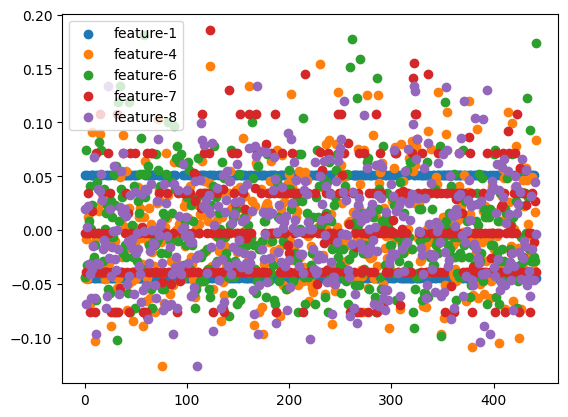

In [80]:
col = [1, 4, 6, 7, 8]
for i in col:
    plt.scatter(df.index, df[i], label=f'feature-{i}')

plt.legend()


In [81]:
class SGDregressor:
    def __init__(self, learning_rate=0.01, epoch=100):
        self.intercept_ = None
        self.coef_ = None
        self.lr = learning_rate
        self.epoch = epoch

    def fit(self, X_train, Y_train):
        # init your coefficient

        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epoch):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0, X_train.shape[0])
                y_hat = np.dot(X_train[idx], self.coef_) + self.intercept_

                inetercept_derivative = -2 * (Y_train[idx] - y_hat)
                self.intercept_ -= self.lr * inetercept_derivative

                coeff_derivative = -2 * np.dot(Y_train[idx] - y_hat, X_train[idx])
                self.coef_ -= self.lr * coeff_derivative
        
        print(self.intercept_, self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [82]:
sgd = SGDregressor(epoch=30, learning_rate=0.01)
start = time.time()
sgd.fit(X_train, Y_train)
print("Time taken to fit the data", time.time() - start)

146.5110429704463 [  62.41074945  -31.51894791  264.38866852  190.56371456   42.14439655
   11.920896   -146.35783984  128.26548819  252.39204676  124.79827455]
Time taken to fit the data 0.06462287902832031


In [83]:
y_pred = sgd.predict(X_test)

In [84]:
print("R2_Score", r2_score(Y_test, y_pred))

R2_Score 0.3936899131898064


In [85]:
class SGDregressor_vlr:
    def __init__(self, learning_rate=0.01, epoch=100):
        self.intercept_ = None
        self.coef_ = None
        self.lr = learning_rate
        self.epoch = epoch

    def fit(self, X_train, Y_train):
        t0, t1 = 5, 50
        def learning_rate(t):
            return t0 / (t + t1)
        # init your coefficient

        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epoch):
            for j in range(X_train.shape[0]):
                self.lr = learning_rate(i * X.shape[0] + j)
                idx = np.random.randint(0, X_train.shape[0])
                y_hat = np.dot(X_train[idx], self.coef_) + self.intercept_

                inetercept_derivative = -2 * (Y_train[idx] - y_hat)
                self.intercept_ -= self.lr * inetercept_derivative

                coeff_derivative = -2 * np.dot(Y_train[idx] - y_hat, X_train[idx])
                self.coef_ -= self.lr * coeff_derivative
        
        print(self.intercept_, self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [86]:
sgd2 = SGDregressor_vlr(epoch=30, learning_rate=0.01)
start = time.time()
sgd2.fit(X_train, Y_train)
print("Time taken to fit the data", time.time() - start)

151.42880301055592 [ 34.44494068  -4.73584056  88.84471403  66.73231074  30.25541917
  20.71382461 -50.66336328  51.31968403  88.09923199  48.81192648]
Time taken to fit the data 0.0782003402709961


In [ ]:
y_pred2 = sgd2.predict(X_test)

print("R2Score", r2_score(Y_test, y_pred2))

R2Score 0.2043483035411211


In [ ]:
print("R2Score_withoutVLR", r2_score(Y_test, y_pred2))
print("")